### CARGAMOS DATASET Y VISUALIZAMOS LOS DATOS

In [1]:
import pandas as pd
import numpy as np


df = pd.read_csv("spoti.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42305 entries, 0 to 42304
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   danceability      42305 non-null  float64
 1   energy            42305 non-null  float64
 2   key               42305 non-null  int64  
 3   loudness          42305 non-null  float64
 4   mode              42305 non-null  int64  
 5   speechiness       42305 non-null  float64
 6   acousticness      42305 non-null  float64
 7   instrumentalness  42305 non-null  float64
 8   liveness          42305 non-null  float64
 9   valence           42305 non-null  float64
 10  tempo             42305 non-null  float64
 11  type              42305 non-null  object 
 12  id                42305 non-null  object 
 13  uri               42305 non-null  object 
 14  track_href        42305 non-null  object 
 15  analysis_url      42305 non-null  object 
 16  duration_ms       42305 non-null  int64 

C:\Users\javie\AppData\Local\Temp\ipykernel_45540\257344949.py:5: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("spoti.csv")


### UTILIZAMOS SOLO COLUMNAS NUMÉRICAS, QUITAMOS NULOS Y NORMALIZAMOS

In [2]:
from sklearn.preprocessing import StandardScaler

df_num = df.select_dtypes(include=['float64'])
df_num = df_num.dropna()


scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_num)
X_scaled

array([[ 1.40177505,  0.676664  , -0.31927979, ...,  1.32372293,
        -0.98078572, -1.73225382],
       [ 1.38107139, -1.50644647, -1.26333168, ...,  0.2567618 ,
        -1.10806566, -1.73208859],
       [ 0.87038117,  0.91827307, -0.27132461, ...,  2.24223729,
        -1.17295348, -1.73192337],
       ...,
       [-1.6692675 , -0.43646347,  0.96885925, ..., -0.79164348,
         0.74302884,  1.73705516],
       [-0.86872607,  0.42642605,  0.38254596, ...,  0.89693848,
         0.42991633,  1.73722039],
       [-0.50986267,  0.63351953,  0.00275497, ..., -0.74525386,
         0.75019593,  1.73738562]])

### REDUCIMOS DIMENSIONALIDAD PROBANDO PCA, TSNE Y UMAP

### PCA

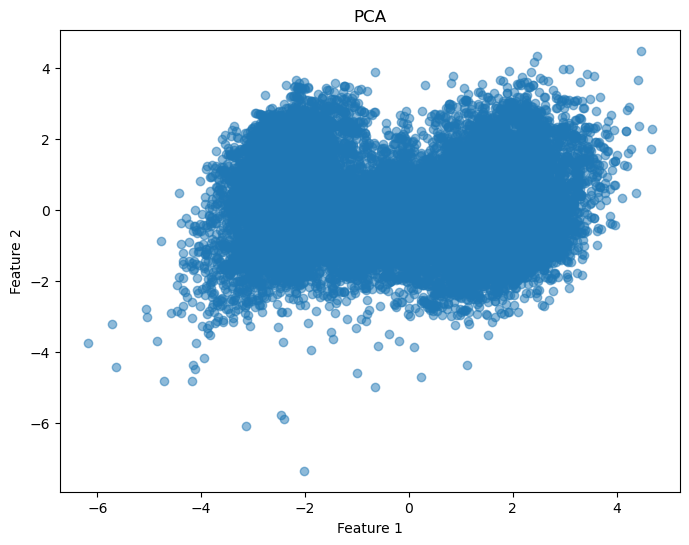

In [3]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title('PCA')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

#### Parece que se observan dos grupos pero no con mucha claridad

### TSNE

c:\Users\javie\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] El sistema no puede encontrar el archivo especificado
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\javie\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
        "wmic CPU Get NumberOfCores /Format:csv".split(),
        capture_output=True,
        text=True,
    )
  File "c:\Users\javie\anaconda3\Lib\subprocess.py", line 554, in run
    with Popen(*popenargs, **kwargs) as process:
         ~~~~~^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\javie\anaconda3\Lib\subprocess.py", line 1039, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
    ~~~~~~~~~~~~~~~~~~~^^^^^^

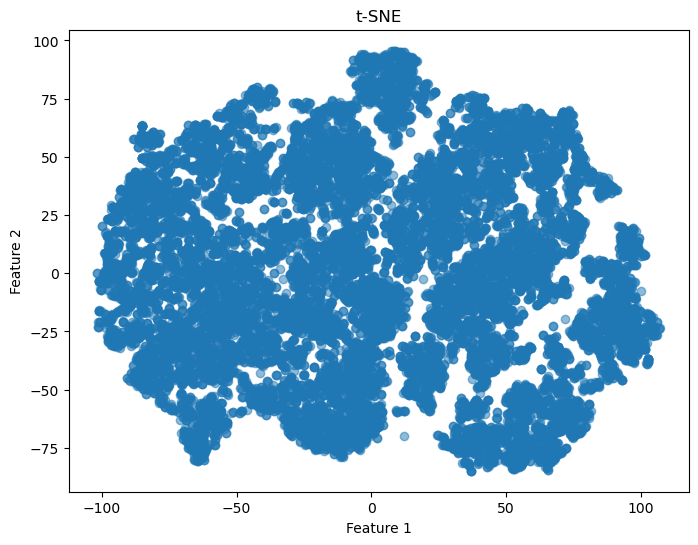

In [4]:
from sklearn.manifold import TSNE

tsme = TSNE(n_components=2, random_state=42)
X_tsme = tsme.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_tsme[:,0], X_tsme[:,1], alpha=0.5)
plt.title('t-SNE')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

#### Aquí no se diferencia ningún grupo

### UMAP

c:\Users\javie\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


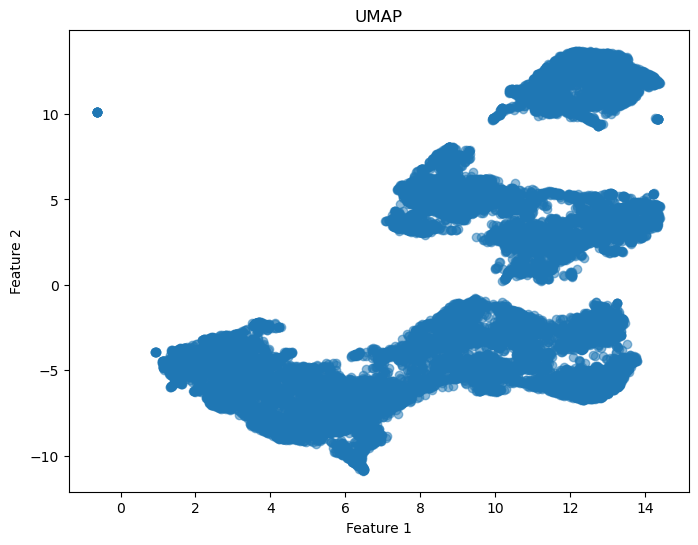

In [5]:
import umap

umap_reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_reducer.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_umap[:,0], X_umap[:,1], alpha=0.5)
plt.title('UMAP')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

#### Aquí se pueden distinguir 3 o 4 grupos de manera más clara

### MÉTODO DEL CODO

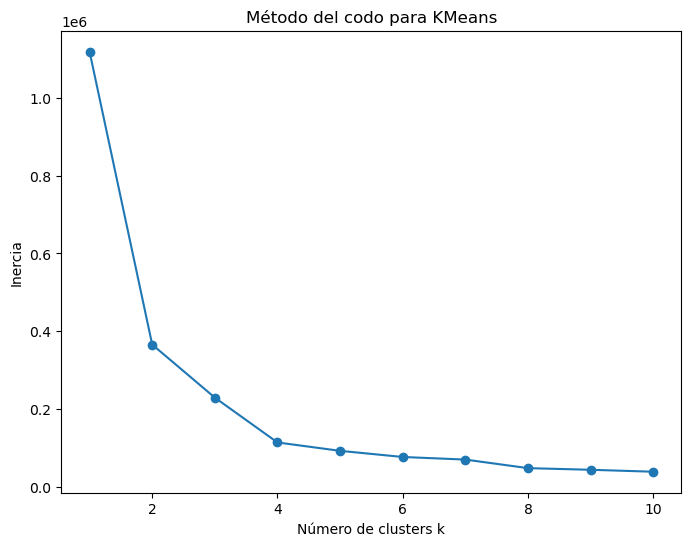

In [8]:
from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_umap)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Método del codo para KMeans')
plt.xlabel('Número de clusters k')
plt.ylabel('Inercia')
plt.show()

### SILHOUETTE SCORE

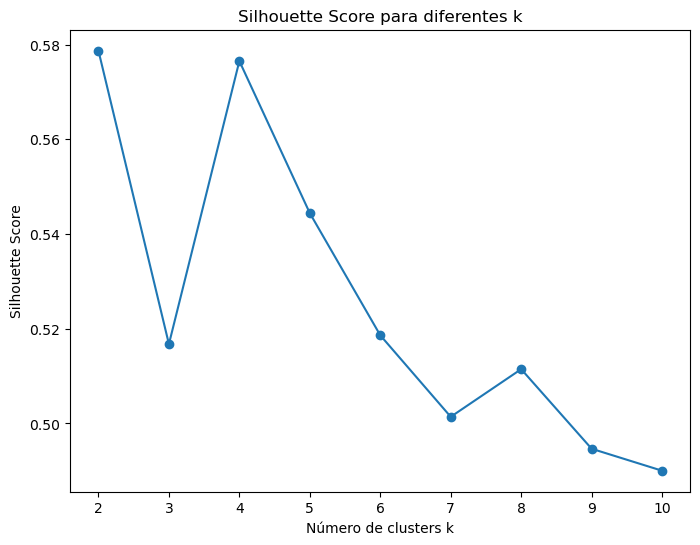

In [9]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_umap)
    score = silhouette_score(X_umap, labels)
    silhouette_scores.append(score)
plt.figure(figsize=(8,6))
plt.plot(range(2, 11), silhouette_scores, marker='o')
plt.title('Silhouette Score para diferentes k')
plt.xlabel('Número de clusters k')
plt.ylabel('Silhouette Score')
plt.show()

Por lo que podemos observar en el método del codo y el silhouette score podemos ver que el número optimo de clusters es k=4

SSE: 113955.2578125
Silhouette Score: 0.5765234


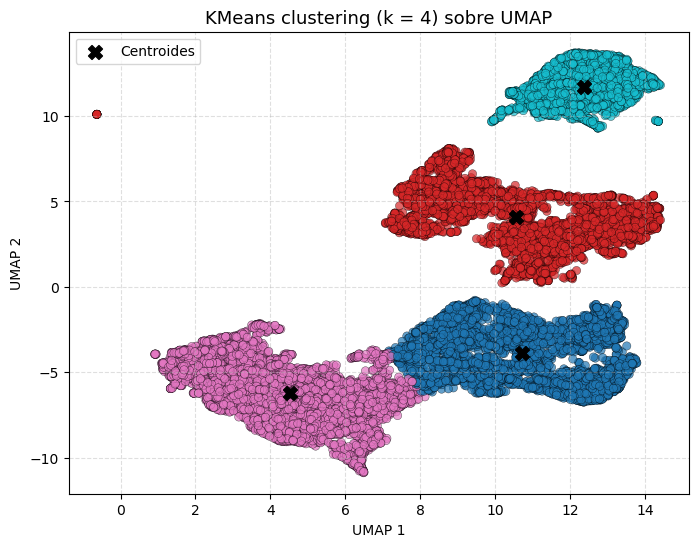

In [12]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
labels = kmeans.fit_predict(X_umap)

# Métricas
SSE = kmeans.inertia_
print("SSE:", SSE)

silhouette = silhouette_score(X_umap, labels)
print("Silhouette Score:", silhouette)

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    c=labels,
    cmap="tab10",
    alpha=0.7,
    edgecolors="k",
    linewidths=0.3
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=100,
    c="black",
    marker="X",
    label="Centroides"
)

plt.title(f"KMeans clustering (k = {k}) sobre UMAP", fontsize=13)
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()
